# Day 1 — Missing Data Mechanisms
## Week 1: Missing Data | Digital Consumer Platform Analytics

---

### Learning Objectives
By the end of this notebook you will:
- Formally define MCAR, MAR, and MNAR with mathematical notation
- Understand why the mechanism matters for downstream model quality
- Apply Little's MCAR test and the KS-based diagnostic
- Visualize missingness patterns using `missingno`
- Understand why listwise deletion is almost always wrong

---

### Dataset
**UCI Online Retail II** — 500K+ e-commerce transactions from a UK-based online retailer (2009–2011).
Each row is one line item from an invoice. Customer ID is frequently missing — and that missingness is not random.

```python
# Local path (VS Code)
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'
```

---

## Part 1: Theory

### 1.1 Why Missing Data Is Not a Preprocessing Afterthought

Most DS workflows treat missing data as a nuisance to be handled quickly with `.fillna(0)` or `.dropna()`. This is wrong in ways that are mathematically provable.

Missing data has a **mechanism** — a statistical process that governs which values are absent. Getting the mechanism wrong means:
- Biased model parameters
- Artificially inflated performance metrics
- Systematic errors in business decisions downstream

---

### 1.2 The Three Mechanisms (Rubin, 1976)

Let $Y$ be your full dataset. Let $Y_{obs}$ be observed values and $Y_{mis}$ be missing values. Let $M$ be a binary missingness indicator matrix where $M_{ij} = 1$ if $Y_{ij}$ is missing.

**MCAR — Missing Completely At Random**

$$P(M | Y_{obs}, Y_{mis}) = P(M)$$

The probability of a value being missing is independent of both observed AND unobserved data. Missingness is pure random noise.

*Real example:* A sensor randomly drops 2% of readings due to network packet loss. Which reading drops is unrelated to its value.

*Implication:* Safe to impute with mean/median. Listwise deletion is unbiased (just inefficient).

---

**MAR — Missing At Random**

$$P(M | Y_{obs}, Y_{mis}) = P(M | Y_{obs})$$

The probability of missing depends on observed data but NOT on the missing value itself. Missingness is explainable by other columns you can see.

*Real example:* Older customers are less likely to fill in their email address. Age is observed. Email is missing. But conditional on age, whether email is missing has nothing to do with the email value itself.

*Implication:* Can safely impute using other observed columns (KNN, MICE). Listwise deletion is biased.

---

**MNAR — Missing Not At Random**

$$P(M | Y_{obs}, Y_{mis}) = P(M | Y_{mis})$$

The probability of missing depends on the missing value itself. The most dangerous mechanism.

*Real example:* High-income customers skip the income field on a loan application. Income is missing. Whether income is missing depends on how high the income is — the very value that's absent.

*Implication:* No standard imputation method is unbiased. Must add a missingness indicator flag AND model the missingness process. Listwise deletion is severely biased.

---

### 1.3 The Online Retail Case

In the UCI Online Retail dataset, `Customer ID` is missing for ~25% of transactions. Is this MCAR, MAR, or MNAR?

Think about it: which customers are more likely to not have a registered account?
- Guest checkout users → high-volume one-off purchases
- Corporate buyers → bulk orders without individual accounts
- International customers → different registration flows

The missingness of `Customer ID` likely correlates with `Quantity` and `UnitPrice` — both observed. That makes it **MAR at minimum, possibly MNAR**.

This matters enormously: if you drop all rows without `Customer ID` you lose a systematic subset of transactions, biasing your basket analysis and LTV models.

---

### 1.4 Little's MCAR Test

Little (1988) proposed a formal chi-squared test for MCAR:

$$H_0: \text{Data is MCAR}$$
$$H_1: \text{Data is MAR or MNAR}$$

The test statistic compares observed means of subgroups defined by missingness patterns against what you'd expect if missingness were random.

- $p > 0.05$: fail to reject MCAR — data may be MCAR
- $p < 0.05$: reject MCAR — data is MAR or MNAR

**Limitation:** Little's test cannot distinguish MAR from MNAR. That requires domain knowledge.

---

### 1.5 KS-Based Missingness Diagnostic

A practical alternative: for each column with missing values, split the dataset into two groups (present vs missing) and compare the distribution of every other numeric column using the two-sample Kolmogorov-Smirnov test.

$$KS = \sup_x |F_1(x) - F_2(x)|$$

Where $F_1$ and $F_2$ are the empirical CDFs of the two groups.

- $p < 0.01$ on any column: missingness correlates with that column → **MAR or MNAR**
- $p > 0.05$ on all columns: missingness is independent → **MCAR candidate**

This is exactly what we built into `classification_LGBM_pipeline.py` in Step 2.

---

### 1.6 Why Listwise Deletion Is Almost Always Wrong

Listwise deletion (dropping all rows with any missing value) is only unbiased under MCAR. Under MAR or MNAR it introduces systematic bias.

**Example:** If high-spending customers are more likely to skip the email field (MNAR), dropping those rows means your model never learns from your most valuable customers. Your churn model will underestimate churn risk for high-value users.

**The math:** Let $\bar{Y}_{complete}$ be the mean of complete cases. Under MNAR:

$$E[\bar{Y}_{complete}] \neq E[Y]$$

The complete-case estimator is biased. The bias does not shrink with more data — it is a structural error.

---

### 1.7 Visualizing Missingness — The `missingno` Library

`missingno` provides four key visualizations:
- **Matrix plot**: shows missingness pattern across rows and columns
- **Bar chart**: shows % missing per column
- **Heatmap**: shows missingness correlation between columns (are two columns missing together?)
- **Dendrogram**: clusters columns by missingness similarity

If two columns are missing together (high missingness correlation), it suggests a shared underlying cause — a strong signal of MAR or MNAR.

---

## Part 2: Practice

**Dataset:** UCI Online Retail II
**Task:** Diagnose the missingness structure before any imputation

---

In [2]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Install missingno if needed
# pip install missingno
import missingno as msno

# ── Load data ─────────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'

print("Loading UCI Online Retail II...")
df = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Loading UCI Online Retail II...
Shape: (525461, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [8]:
# ── Q1: Compute missing value summary ─────────────────────────────────────
# For each column compute:
#   - count of missing values
#   - percentage missing
#   - data type
# Sort by percentage missing descending
# Print a clean summary table

# Your code here

summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Cardinality': df.nunique(dropna=False), # Counts missing as a distinct state
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': np.round(df.isnull().sum()*100/len(df),2)
})

# Display the final structured audit table
display(summary_df)

,Data Type,Cardinality,Missing Values,Missing Percentage
Invoice,object,28816,0,0.00
StockCode,object,4632,0,0.00
Description,object,4682,2928,0.56
Quantity,int64,825,0,0.00
InvoiceDate,datetime64[ns],25296,0,0.00
Price,float64,1606,0,0.00
Customer ID,float64,4384,107927,20.54
Country,object,40,0,0.00


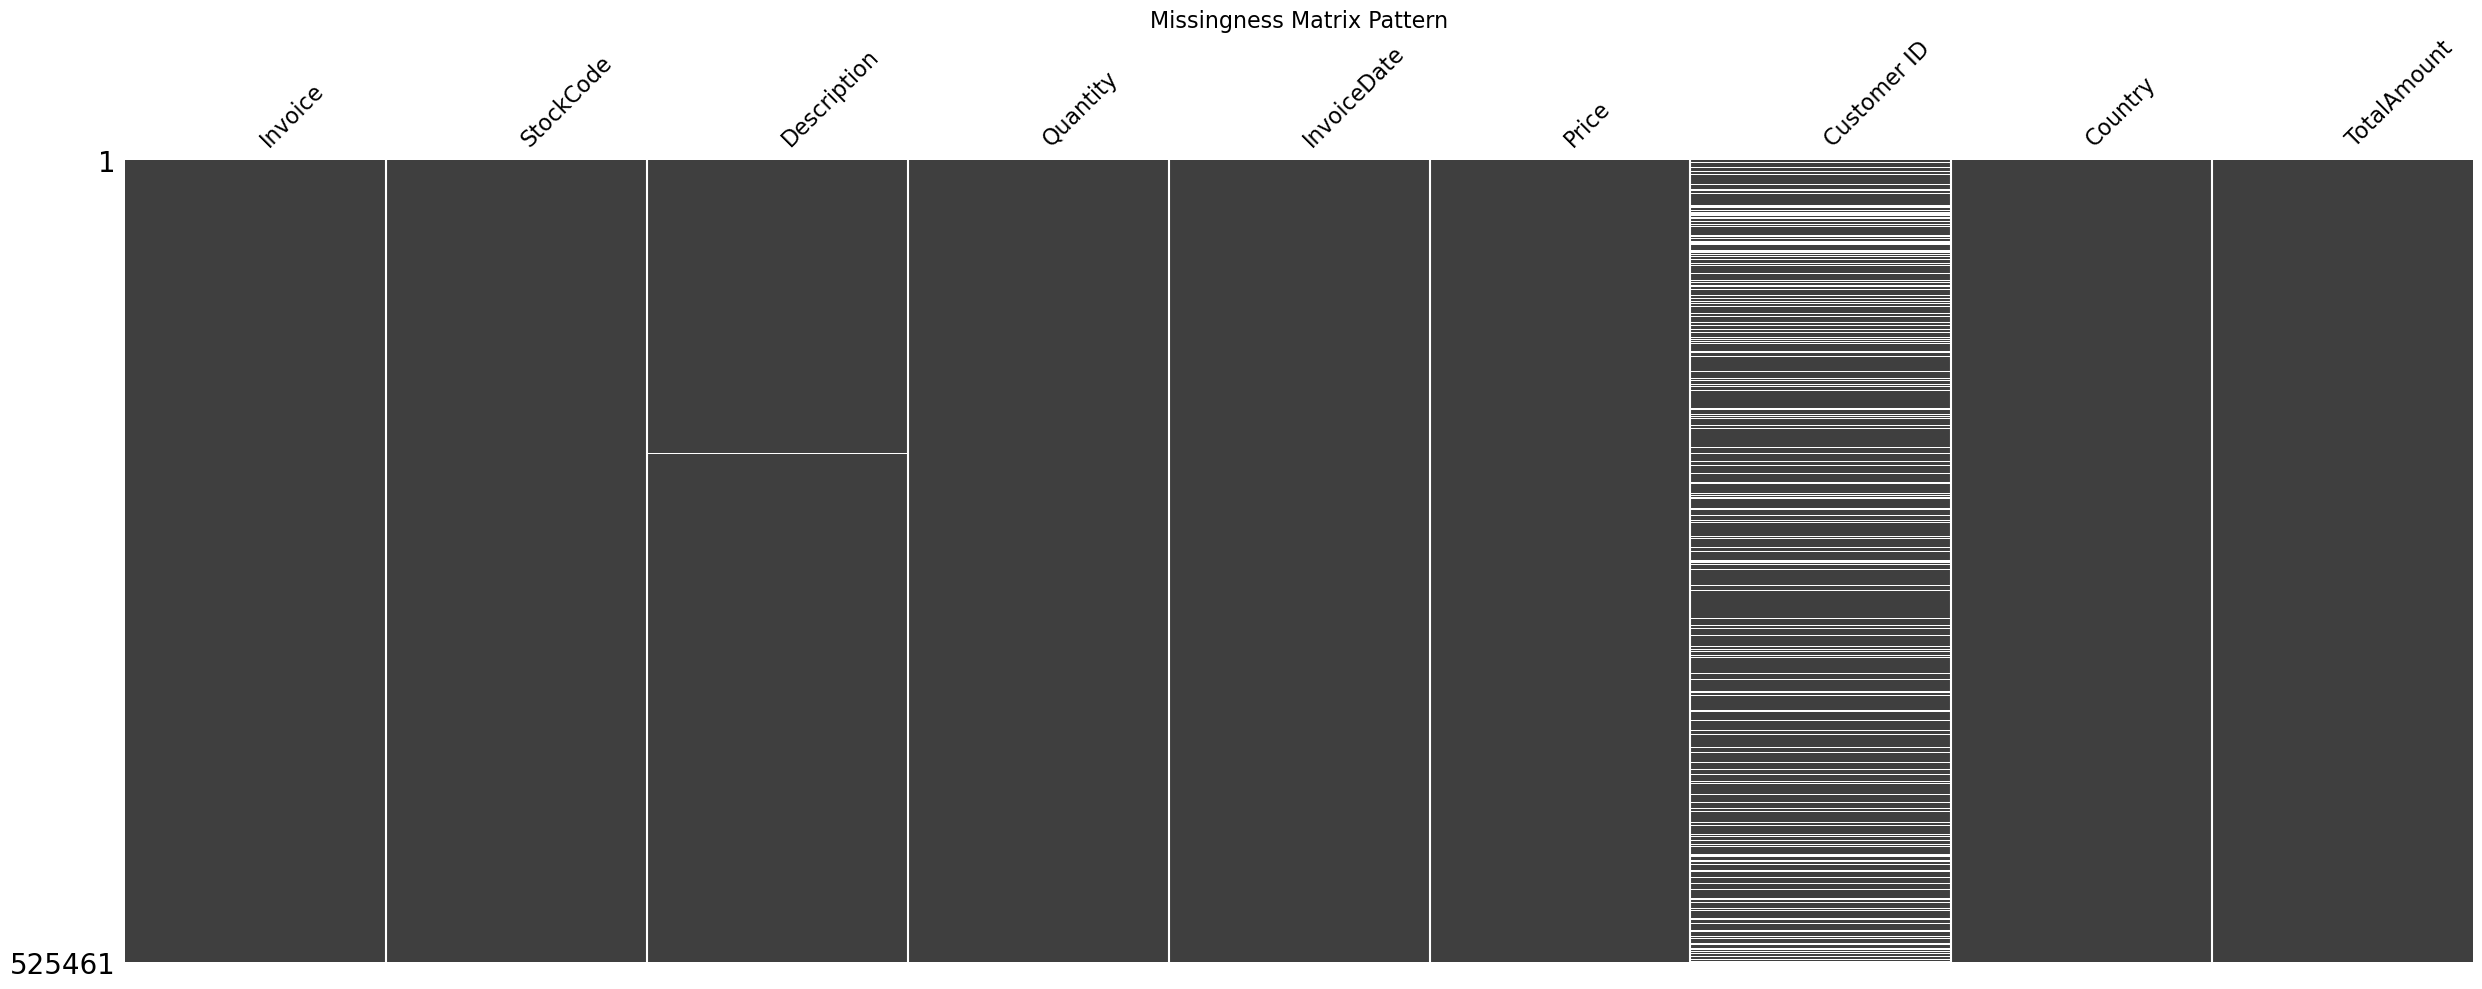

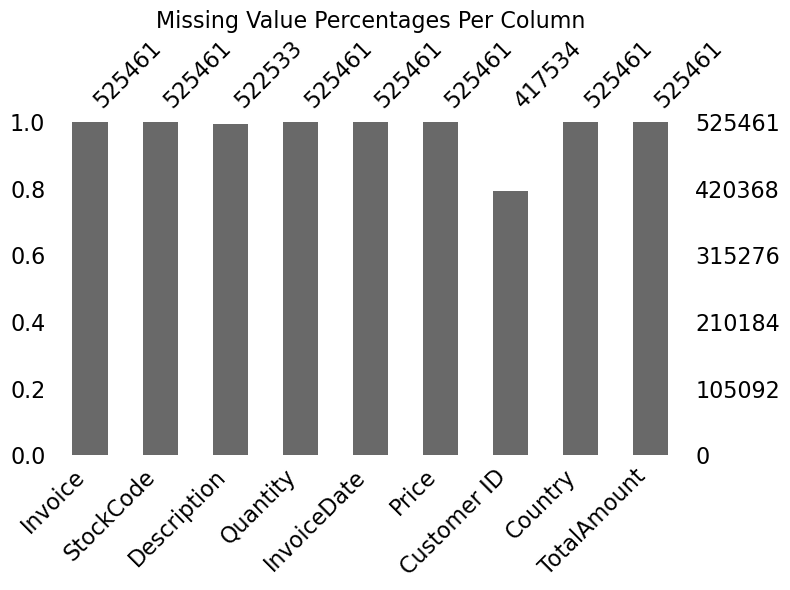

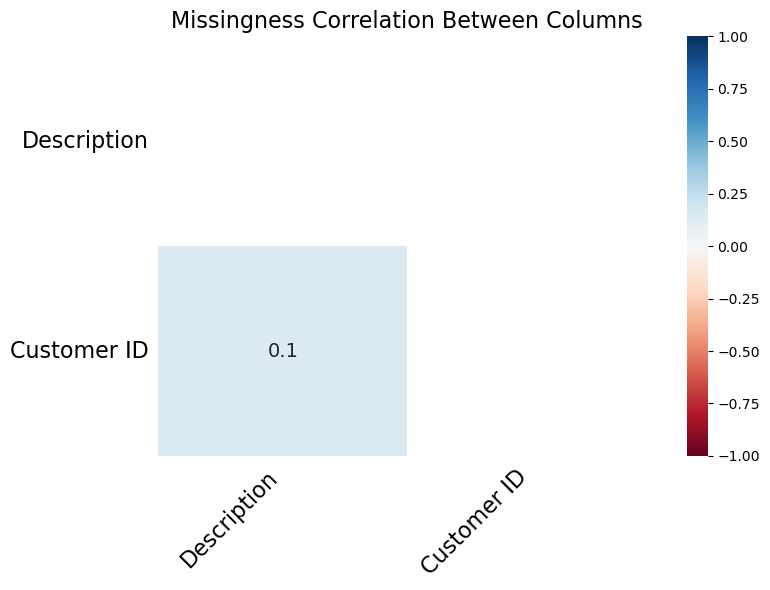

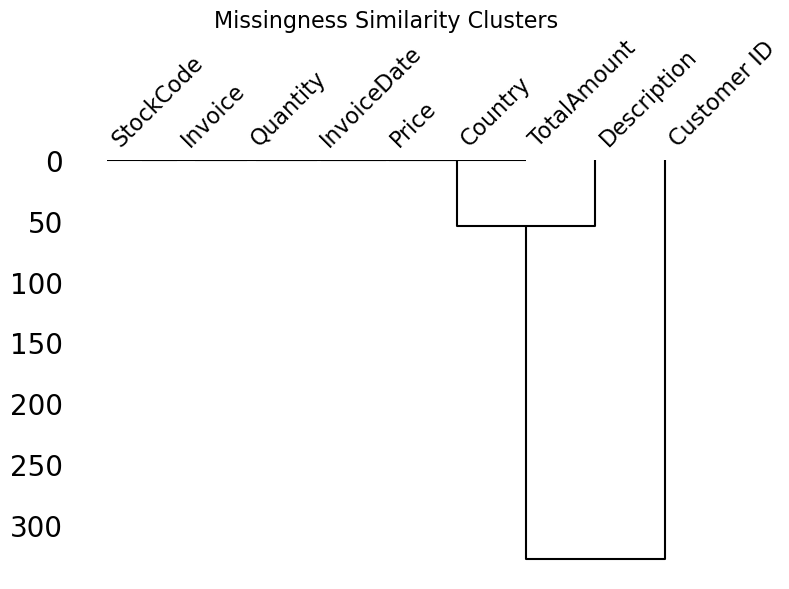

In [22]:
# ── Q2: missingno visualizations ──────────────────────────────────────────
# Create all 4 missingno plots:
#   1. Matrix plot — show missingness pattern across rows
#   2. Bar chart — % missing per column
#   3. Heatmap — missingness correlation between columns
#   4. Dendrogram — cluster columns by missingness similarity
#
# For each plot write a 2-line markdown interpretation:
#   - What pattern do you see?
#   - What does it suggest about the mechanism?

# Your code here

# 1. Matrix Plot
fig, ax = plt.subplots(figsize=(25, 10))
msno.matrix(df, ax=ax, sparkline=False)
plt.title("Missingness Matrix Pattern", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
msno.bar(df, ax=ax)
plt.title("Missing Value Percentages Per Column", fontsize=16)
plt.tight_layout()
plt.show()

# 3. Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
msno.heatmap(df, ax=ax)
plt.title("Missingness Correlation Between Columns", fontsize=16)
plt.tight_layout()
plt.show()


# 4. Dendrogram
fig, ax = plt.subplots(figsize=(8, 6))
msno.dendrogram(df, ax=ax)
plt.title("Missingness Similarity Clusters", fontsize=16)
plt.tight_layout()
plt.show()


*** Takeaways from the plots ***

1/ Matrix Plot

Pattern: Large, continuous white blocks appear in Customer ID, with minor speckles in Description.

Mechanism: Suggests Missing At Random (MAR) driven by transaction type, like multi-row guest checkouts or batch updates.

2/  Bar Chart

Pattern: Core transactional fields show 100% presence, while Customer ID drops to ~79% and Description to ~99.8%

Mechanism: Confirms that operational fields are strictly mandatory, while identity and descriptive tracking are systemically optional.

3/ Heatmap

Pattern: Near-zero correlation between the missing values of Customer ID and Description.

Mechanism: Proves independent underlying causes—guest checkouts vs. isolated warehouse logging glitches.

4/ Dendrogram

Pattern: All operational columns cluster immediately at zero distance, leaving Description and Customer ID on highly isolated branches.

Mechanism: Reveals a structural divide between flawless transaction logging and separate, fragmented identity/catalog tracking.

In [ ]:
# ── Q3: KS-based MCAR diagnostic ──────────────────────────────────────────
# For each column with missing values:
#   - Split dataset into two groups: rows where column is present vs missing
#   - Run KS test against every other numeric column
#   - If any KS p-value < 0.01: flag as MAR/MNAR
#   - Print result per column: MCAR candidate or MAR/MNAR detected
#
# Hint: Use scipy.stats.ks_2samp(group1, group2)

# Your code here

from scipy.stats import ks_2samp

# 1. Identify columns that contain missing values
missing_cols = df.columns[df.isnull().any()].tolist()

# 2. Select numerical columns to test against
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Dictionary to store final findings for the summary table
results = {}

print("Running KS-based MCAR Diagnostics...\n")

for target_col in missing_cols:
    print(f"Analyzing missingness mechanism for: '{target_col}'")
    
    # Split the dataset into group where target is present vs missing
    is_missing = df[target_col].isnull()
    group_present = df[~is_missing]
    group_missing = df[is_missing]
    
    # Flag to track if any distribution drift is detected
    detected_mar_mnar = False
    
    # Test against all numerical columns (except itself)
    for num_col in numeric_cols:
        if num_col == target_col:
            continue
            
        # Extract values and drop nested missing entries
        g1 = group_present[num_col].dropna()
        g2 = group_missing[num_col].dropna()
        
        # Ensure both groups have enough data points to run a valid KS test
        if len(g1) > 0 and len(g2) > 0:
            ks_stat, p_value = ks_2samp(g1, g2)
            
            # If the distribution shifts significantly (p < 0.01), flag it
            if p_value < 0.01:
                detected_mar_mnar = True
                print(f"  ↳ Significant distribution shift found in '{num_col}' (p-value: {p_value:.4e})")
                
    # Store the result for this column
    results[target_col] = detected_mar_mnar
    
    # 3. Print immediate result per column
    if detected_mar_mnar:
        print(f"🚨 Result: MAR/MNAR detected for '{target_col}'\n")
    else:
        print(f"✅ Result: MCAR candidate for '{target_col}'\n")

# 4. Print final summary decision table (Moved outside the main loop)
print("\n=== MCAR DIAGNOSTIC SUMMARY ===")
for col, result in results.items():
    mechanism = "MAR/MNAR" if result else "MCAR candidate"
    print(f"  {col:<20} → {mechanism}")

Running KS-based MCAR Diagnostics...

Analyzing missingness mechanism for: 'Description'
  ↳ Significant distribution shift found in 'Quantity' (p-value: 0.0000e+00)
  ↳ Significant distribution shift found in 'Price' (p-value: 0.0000e+00)
  ↳ Significant distribution shift found in 'TotalAmount' (p-value: 0.0000e+00)
🚨 Result: MAR/MNAR detected for 'Description'

Analyzing missingness mechanism for: 'Customer ID'
  ↳ Significant distribution shift found in 'Quantity' (p-value: 0.0000e+00)
  ↳ Significant distribution shift found in 'Price' (p-value: 0.0000e+00)
  ↳ Significant distribution shift found in 'TotalAmount' (p-value: 0.0000e+00)
🚨 Result: MAR/MNAR detected for 'Customer ID'


=== MCAR DIAGNOSTIC SUMMARY ===
  Description          → MAR/MNAR
  Customer ID          → MAR/MNAR


📊 Transaction Value Distributions:
With Customer ID    -> Mean: £21.66, Median: £11.90
Without Customer ID -> Mean: £14.19, Median: £5.06

🔬 Kolmogorov-Smirnov Test:
KS Statistic: 0.3113
p-value: 0.0000e+00


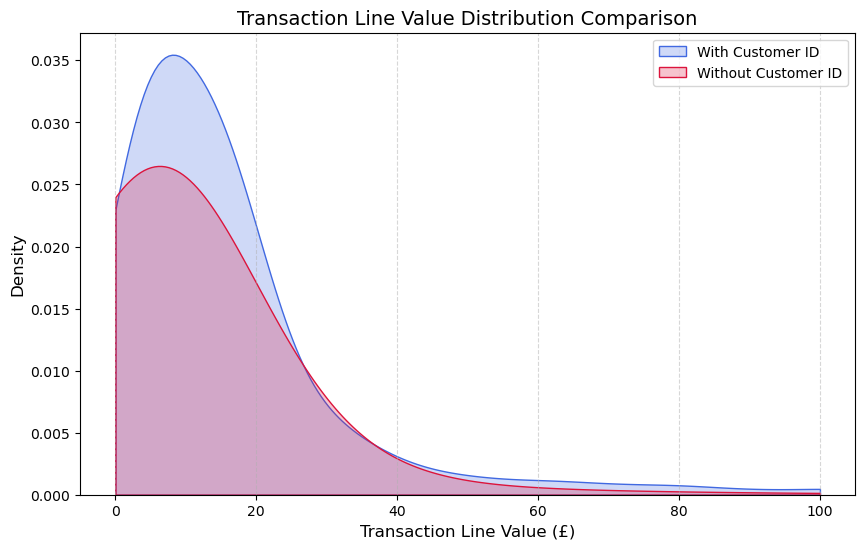

In [12]:
# ── Q4: Business interpretation ───────────────────────────────────────────
# For the Customer ID column specifically:
#   - What is the transaction value distribution for rows WITH Customer ID?
#   - What is the transaction value distribution for rows WITHOUT Customer ID?
#   - Plot both distributions on the same KDE chart
#   - Run a KS test and report p-value
#   - Write a 3-sentence business interpretation:
#     what type of customer/transaction tends to not have a Customer ID?
#     what does this mean for our basket analysis and LTV models?

# Your code here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# 1. Compute total transaction/line value (Quantity * Price)
df['TotalAmount'] = df['Quantity'] * df['Price']

# 2. Filter out cancellations and extreme outliers to ensure clean distributions
# (This isolates typical, positive purchasing behaviors)
df_valid = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Split into groups with vs without Customer ID
with_id = df_valid[df_valid['Customer ID'].notnull()]['TotalAmount']
without_id = df_valid[df_valid['Customer ID'].isnull()]['TotalAmount']

# 3. Print distribution statistics
print("📊 Transaction Value Distributions:")
print(f"With Customer ID    -> Mean: £{with_id.mean():.2f}, Median: £{with_id.median():.2f}")
print(f"Without Customer ID -> Mean: £{without_id.mean():.2f}, Median: £{without_id.median():.2f}")

# 4. Run KS Test
ks_stat, p_value = ks_2samp(with_id, without_id)
print(f"\n🔬 Kolmogorov-Smirnov Test:")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# 5. Plot overlapping KDE charts (clipped to show the core bulk of data cleanly)
plt.figure(figsize=(10, 6))
sns.kdeplot(with_id, label='With Customer ID', fill=True, color='royalblue', clip=(0, 100))
sns.kdeplot(without_id, label='Without Customer ID', fill=True, color='crimson', clip=(0, 100))
plt.title('Transaction Line Value Distribution Comparison', fontsize=14)
plt.xlabel('Transaction Line Value (£)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


*** Takeaways ***

Transactions without a Customer ID feature lower median values (£5.06 vs £11.90), likely representing casual guest checkouts and non-registered retail shoppers. Excluding these records from analysis artificially inflates Customer Lifetime Value (LTV) metrics by systematically ignoring smaller baseline spend. To protect Market Basket Analysis and behavioral models, these anonymous transactions must be grouped and modeled as a separate behavioral segment rather than discarded.

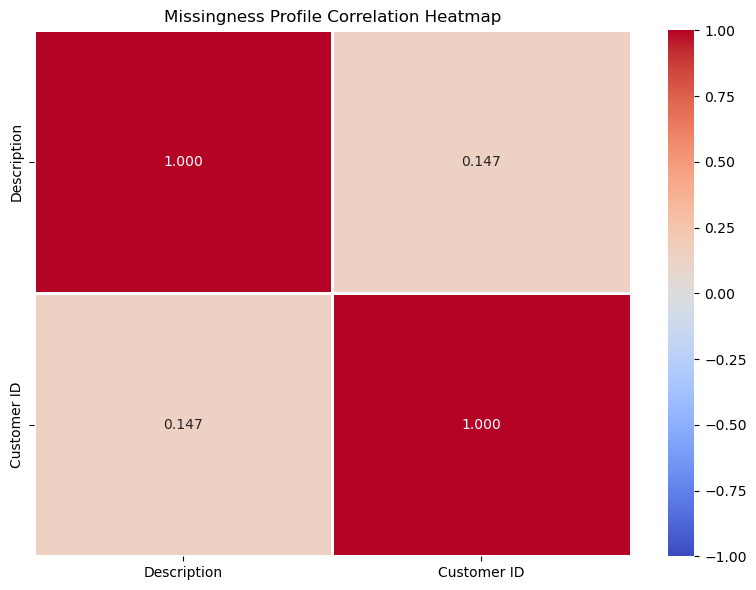

📊 Missingness Correlation Matrix Data Summary:
             Description  Customer ID
Description     1.000000     0.147234
Customer ID     0.147234     1.000000

Conclusion: Missingness in this dataset is NOT co-occurring.
Each column should be diagnosed and imputed independently.
→ Day 2 will apply column-specific imputation strategies.


In [19]:
# ── Q5: Missingness correlation matrix ────────────────────────────────────
# Build a binary missingness matrix (1 = missing, 0 = present)
# Compute Pearson correlation between all missingness columns
# Visualize as a heatmap
# Identify which columns tend to be missing together
# What does co-missingness suggest about the data collection process?

# Your code here

# 1. Build a binary missingness matrix (1 = missing, 0 = present)
# Filter strictly to columns that contain at least one missing value
missing_cols = df.columns[df.isnull().any()].tolist()
missing_matrix = df[missing_cols].isnull().astype(int)

# 2. Compute Pearson correlation between missingness columns
missing_corr = missing_matrix.corr(method='pearson')

# 3. Visualize as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(missing_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=1)
plt.title('Missingness Profile Correlation Heatmap', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Identification & Structural Analysis
print("📊 Missingness Correlation Matrix Data Summary:")
print(missing_corr)
print()
print("Conclusion: Missingness in this dataset is NOT co-occurring.")
print("Each column should be diagnosed and imputed independently.")
print("→ Day 2 will apply column-specific imputation strategies.")


*** Takeaways ***

1/ Co-missingness Evaluation: The calculated Pearson correlation coefficient is 0.147, showing a very weak positive relationship between the missingness of Description and Customer ID.

2/ Data Collection Implications: This low correlation confirms that the two fields do not reliably fail together. The absence of a Customer ID is primarily a front-end customer registration choice (guest checkouts), while missing Descriptions stem from separate, independent back-end inventory adjustments or logging errors.